Extracts structures from a relax file.

In [15]:
import numpy as np
import ase
from ase.visualize import view
from ase.build import make_supercell
from ase import Atoms
from ase.io import iread
import matplotlib.pyplot as plt

In [16]:
CONFIG = {
    'path': './',
    'filename': 'Pt-water-ontop',

    'supercell_size': [2,2,1]
}

In [17]:
relax_images = Atoms()
relax_positions = []
output_file = CONFIG['path'] + CONFIG['filename'] + '-success/' + CONFIG['filename'] + '.relax.out'
# iterate over each line in output_file and find each instance of ATOMIC_POSITIONS. Then add the next lines until reach empty lines/"Writing config-only".
relax_images = list(iread(output_file))
print(relax_images)

[Atoms(symbols='H24O12Pt36', pbc=True, cell=[[8.315575849598094, 0.0, 0.0], [4.157787924799047, 7.20149657514819, 0.0], [0.0, 0.0, 26.78964209973391]], calculator=SinglePointDFTCalculator(...)), Atoms(symbols='H24O12Pt36', pbc=True, cell=[[8.315575849598094, 0.0, 0.0], [4.157787924799047, 7.20149657514819, 0.0], [0.0, 0.0, 26.78964209973391]], calculator=SinglePointDFTCalculator(...)), Atoms(symbols='H24O12Pt36', pbc=True, cell=[[8.315575849598094, 0.0, 0.0], [4.157787924799047, 7.20149657514819, 0.0], [0.0, 0.0, 26.78964209973391]], calculator=SinglePointDFTCalculator(...)), Atoms(symbols='H24O12Pt36', pbc=True, cell=[[8.315575849598094, 0.0, 0.0], [4.157787924799047, 7.20149657514819, 0.0], [0.0, 0.0, 26.78964209973391]], calculator=SinglePointDFTCalculator(...)), Atoms(symbols='H24O12Pt36', pbc=True, cell=[[8.315575849598094, 0.0, 0.0], [4.157787924799047, 7.20149657514819, 0.0], [0.0, 0.0, 26.78964209973391]], calculator=SinglePointDFTCalculator(...)), Atoms(symbols='H24O12Pt36', p

In [18]:
view(relax_images[0], viewer='x3d')

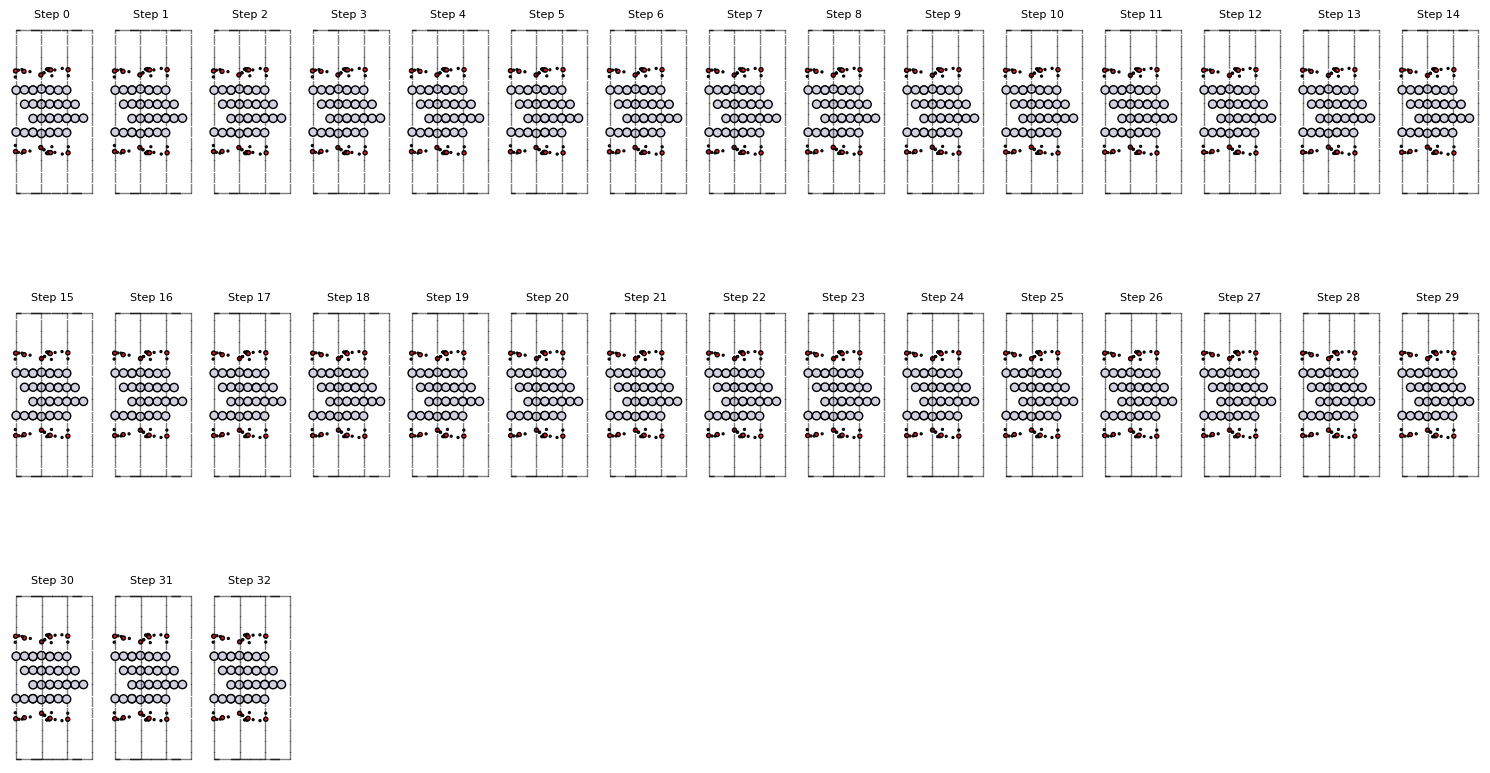

In [19]:
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
import math

n = len(relax_images)
ncols = math.ceil(math.sqrt(n)*2.5)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, 3 * nrows))
axes = axes.flatten()

for i, atoms in enumerate(relax_images):
    plot_atoms(atoms, axes[i], radii=0.5, rotation=('90x,0y,0z'))
    axes[i].set_title(f'Step {i}', fontsize=8)
    axes[i].axis('off')

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Plot energies

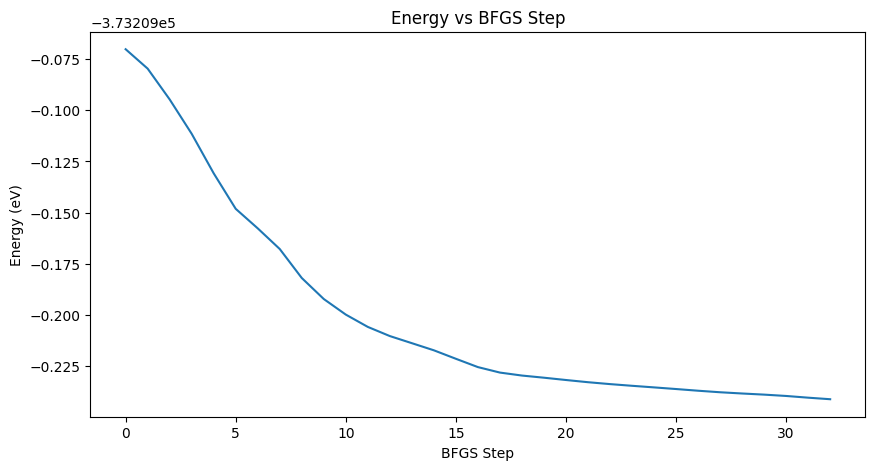

In [20]:
plotting_energies = []
for i, atoms in enumerate(relax_images):
    plotting_energies.append(atoms.get_potential_energy())

plt.figure(figsize=(10, 5))
plt.plot(plotting_energies)
plt.xlabel('BFGS Step')
plt.ylabel('Energy (eV)')
plt.title('Energy vs BFGS Step')
plt.show()